## ZADANIE - Monte Carlo dla modelu Isinga z użyciem Numba

### WERSJA BEZ NUMBY

Rozpoczynanie symulacji...
Czas wykonania: 4.8030 sekund.


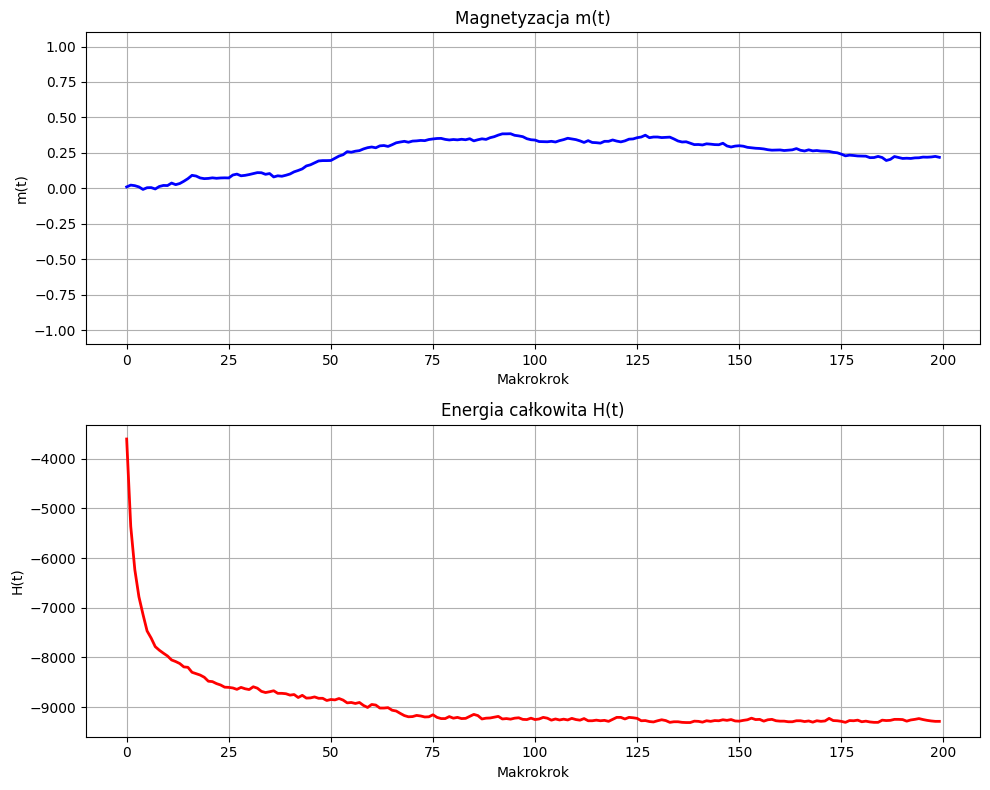

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import time
from numba import njit
from IPython.display import display, HTML

def sum_neighbors(S, i, j, N):
    top = (i - 1) % N
    bottom =  (i + 1) % N
    left = (j - 1) % N
    right = (j + 1) % N
    return (S[top, j] + S[bottom, j] + S[i, left] + S[i, right] +
            S[top, left] + S[top, right] + S[bottom, left] + S[bottom, right])

def delta_e(S, i, j, N, J, B):
    return 2.0 * S[i, j] * (J * sum_neighbors(S, i, j, N) + B)

def total_energy(S, N, J, B):
    energy = 0.0
    for i in range(N):
        for j in range(N):
            energy += -J * S[i, j] * sum_neighbors(S, i, j, N) / 2.0
            energy -= B * S[i, j]
    return energy

def try_rotate(S, i, j, N, J, B, beta):
    dE = delta_e(S, i, j, N, J, B)
    if dE < 0 or np.random.rand() < np.exp(-beta * dE):
        S[i, j] = -S[i, j]
        return True, dE
    return False, 0.0

def macrostep(S, N, J, B, beta, current_energy, current_magnetization):
    num_trials = N * N
    for _ in range(num_trials):
        i = np.random.randint(0, N)
        j = np.random.randint(0, N)
        
        old_spin = S[i, j]
        succesful, dE = try_rotate(S, i, j, N, J, B, beta)
        
        if succesful:
            current_energy += dE
            current_magnetization += 2 * (-old_spin)
            
    return current_energy, current_magnetization


# SYMULACJA

N = 50         
J = 1.0        
B = 0.0        
beta = 0.5     
M = 200

grid = np.random.choice([-1, 1], size=(N, N)).astype(np.int8)

# Inicjalizacja zmiennych śledzących
current_energy = total_energy(grid, N, J, B)
current_magnetization = np.sum(grid)

grid_history = []
energy_history = np.zeros(M)
magnetization_history = np.zeros(M)

print(f"Rozpoczynanie symulacji...")
start_time = time.perf_counter()

for step in range(M):
    current_energy, current_magnetization = macrostep(
        grid, N, J, B, beta, current_energy, current_magnetization
    )
    
    grid_history.append(grid.copy())
    energy_history[step] = current_energy
    magnetization_history[step] = current_magnetization / (N * N)

end_time = time.perf_counter()
print(f"Czas wykonania: {end_time - start_time:.4f} sekund.")


# WYKRESY 

fig_plots, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(magnetization_history, color='blue', linewidth=2)
ax1.set_title('Magnetyzacja m(t)')
ax1.set_xlabel('Makrokrok')
ax1.set_ylabel('m(t)')
ax1.set_ylim(-1.1, 1.1)
ax1.grid(True)

ax2.plot(energy_history, color='red', linewidth=2)
ax2.set_title('Energia całkowita H(t)')
ax2.set_xlabel('Makrokrok')
ax2.set_ylabel('H(t)')
ax2.grid(True)

plt.tight_layout()
plt.show()

# ANIMACJA

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_title(f"Model Isinga")
ax.axis('off')  

image = ax.imshow(grid_history[0], cmap='coolwarm', vmin=-1, vmax=1)

def update_frame(frame_index):
    image.set_array(grid_history[frame_index])
    return image,

animation_obj = animation.FuncAnimation(
    fig, 
    update_frame, 
    frames=M, 
    interval=50, 
    blit=False 
)

plt.close(fig)
display(HTML(animation_obj.to_jshtml()))

### Wersja z numbą

Rozpoczynanie symulacji...
Czas wykonania: 0.3211 sekund.


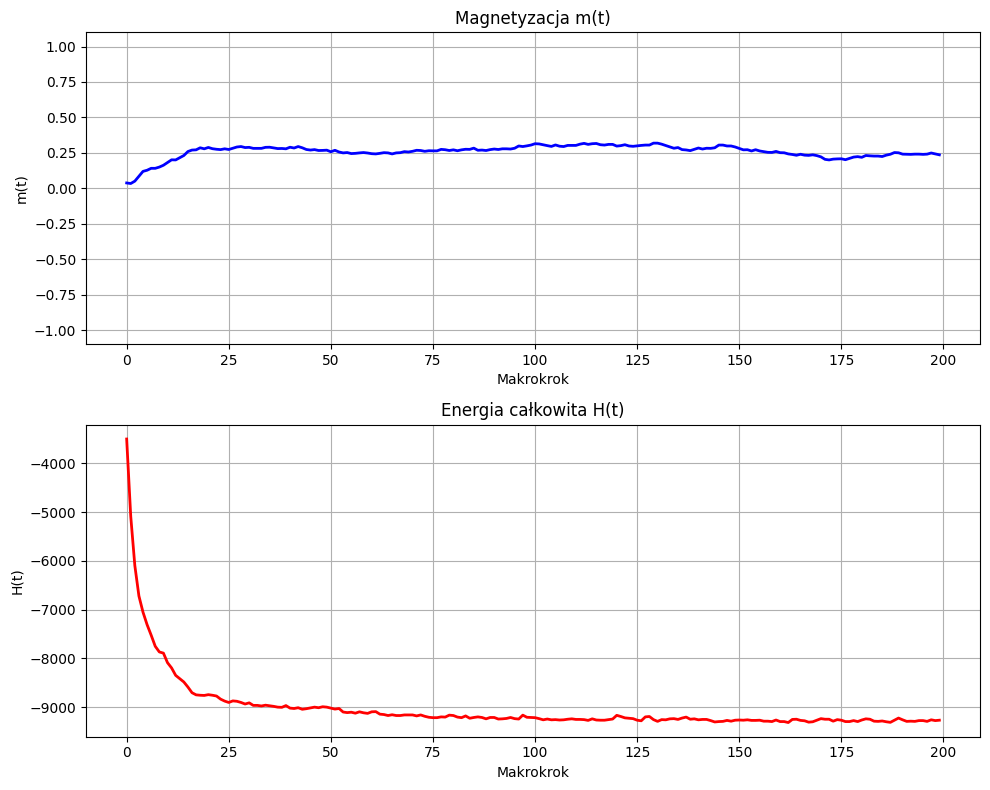

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import time
from numba import njit
from IPython.display import display, HTML

@njit
def sum_neighbors(S, i, j, N):
    top = (i - 1) % N
    bottom =  (i + 1) % N
    left = (j - 1) % N
    right = (j + 1) % N
    return (S[top, j] + S[bottom, j] + S[i, left] + S[i, right] +
            S[top, left] + S[top, right] + S[bottom, left] + S[bottom, right])

@njit
def delta_e(S, i, j, N, J, B):
    return 2.0 * S[i, j] * (J * sum_neighbors(S, i, j, N) + B)

@njit
def total_energy(S, N, J, B):
    energy = 0.0
    for i in range(N):
        for j in range(N):
            energy += -J * S[i, j] * sum_neighbors(S, i, j, N) / 2.0
            energy -= B * S[i, j]
    return energy

@njit
def try_rotate(S, i, j, N, J, B, beta):
    dE = delta_e(S, i, j, N, J, B)
    if dE < 0 or np.random.rand() < np.exp(-beta * dE):
        S[i, j] = -S[i, j]
        return True, dE
    return False, 0.0

@njit
def macrostep(S, N, J, B, beta, current_energy, current_magnetization):
    num_trials = N * N
    for _ in range(num_trials):
        i = np.random.randint(0, N)
        j = np.random.randint(0, N)
        
        old_spin = S[i, j]
        succesful, dE = try_rotate(S, i, j, N, J, B, beta)
        
        if succesful:
            current_energy += dE
            current_magnetization += 2 * (-old_spin)
            
    return current_energy, current_magnetization


# SYMULACJA

N = 50         
J = 1.0        
B = 0.0        
beta = 0.5     
M = 200

grid = np.random.choice([-1, 1], size=(N, N)).astype(np.int8)

# Inicjalizacja zmiennych śledzących
current_energy = total_energy(grid, N, J, B)
current_magnetization = np.sum(grid)

grid_history = []
energy_history = np.zeros(M)
magnetization_history = np.zeros(M)

print(f"Rozpoczynanie symulacji...")
start_time = time.perf_counter()

for step in range(M):
    current_energy, current_magnetization = macrostep(
        grid, N, J, B, beta, current_energy, current_magnetization
    )
    
    grid_history.append(grid.copy())
    energy_history[step] = current_energy
    magnetization_history[step] = current_magnetization / (N * N)

end_time = time.perf_counter()
print(f"Czas wykonania: {end_time - start_time:.4f} sekund.")


# WYKRESY 

fig_plots, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(magnetization_history, color='blue', linewidth=2)
ax1.set_title('Magnetyzacja m(t)')
ax1.set_xlabel('Makrokrok')
ax1.set_ylabel('m(t)')
ax1.set_ylim(-1.1, 1.1)
ax1.grid(True)

ax2.plot(energy_history, color='red', linewidth=2)
ax2.set_title('Energia całkowita H(t)')
ax2.set_xlabel('Makrokrok')
ax2.set_ylabel('H(t)')
ax2.grid(True)

plt.tight_layout()
plt.show()

# ANIMACJA

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_title(f"Model Isinga")
ax.axis('off')  

image = ax.imshow(grid_history[0], cmap='coolwarm', vmin=-1, vmax=1)

def update_frame(frame_index):
    image.set_array(grid_history[frame_index])
    return image,

animation_obj = animation.FuncAnimation(
    fig, 
    update_frame, 
    frames=M, 
    interval=50, 
    blit=False 
)

plt.close(fig)
display(HTML(animation_obj.to_jshtml()))